In [30]:
import pandas as pd


In [31]:
# read pickle files mapping_N_N1 and mapping_N1_N
df_N_N1 = pd.read_pickle("mapping_N_N1.pkl")
df_N1_N = pd.read_pickle("mapping_N1_N.pkl")

Combine forward and reverse mappings

In [32]:
df_N1_N = pd.read_pickle("filtered_N1_N.pkl")

# Add new columns
df_N1_N["Mapped 2023 HS"] = None
df_N1_N["Mapped 2023 Description"] = None

# Build a lookup: (year_N1, HS_N1) -> row index
lookup = {(row.year_N1, row.HS_N1): idx for idx, row in df_N1_N.iterrows()}

In [33]:
# For each row where year_N1 == 2023, start the chain
for idx, row in df_N1_N[df_N1_N["year_N1"] == 2023].iterrows():
    mapped_2023_hs = row.HS_N1
    mapped_2023_desc = row.Description_N1
    current_year_N = row.year_N
    current_hs_N = row.HS_N

    # Set for the 2023 row itself
    df_N1_N.at[idx, "Mapped 2023 HS"] = mapped_2023_hs
    df_N1_N.at[idx, "Mapped 2023 Description"] = mapped_2023_desc

    # Follow the chain backward
    while (current_year_N, current_hs_N) in lookup:
        next_idx = lookup[(current_year_N, current_hs_N)]
        df_N1_N.at[next_idx, "Mapped 2023 HS"] = mapped_2023_hs
        df_N1_N.at[next_idx, "Mapped 2023 Description"] = mapped_2023_desc

        # Move to the next mapping in the chain
        next_row = df_N1_N.loc[next_idx]
        current_year_N = next_row.year_N
        current_hs_N = next_row.HS_N

In [34]:
# count the number of missing values in the Mapped_2023_HS column for each year
df_N1_N["Mapped 2023 HS"].isna().sum()


327325

In [36]:
df_N1_N

,from_year,to_year,year_N,year_N1,HS_N,HS_N1,Cosine_Similarity,Jaccard_Similarity,Levenshtein_Similarity,Combined_Similarity,Description_N,Description_N1,Mapped 2023 HS,Mapped 2023 Description
0,2023,2022,2022,2023,01013000,01013000,1.000000,1.000000,1.000000,1.000000,Live asses,Live asses,01013000,Live asses
1,2023,2022,2022,2023,01031000,01031000,1.000000,1.000000,1.000000,1.000000,Live purebred breeding swine,Live purebred breeding swine,01031000,Live purebred breeding swine
2,2023,2022,2022,2023,01022920,01022920,1.000000,1.000000,1.000000,1.000000,Cows imported specially for dairy purposes,Cows imported specially for dairy purposes,01022920,Cows imported specially for dairy purposes
3,2023,2022,2022,2023,01019040,01019040,1.000000,1.000000,1.000000,1.000000,Mules and hinnies not imported for immediate s...,Mules and hinnies not imported for immediate s...,01019040,Mules and hinnies not imported for immediate s...
4,2023,2022,2022,2023,01012900,01012900,1.000000,1.000000,1.000000,1.000000,Live horses other than purebred breeding horses,Live horses other than purebred breeding horses,01012900,Live horses other than purebred breeding horses
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
758523,1790,1789,1789,1790,nan,nan,1.000000,1.000000,1.000000,1.000000,"canes, walking sticks and whips","canes, walking sticks and whips",None,None
758524,1790,1789,1789,1790,nan,nan,0.846574,0.142857,0.560748,0.677248,"anchors, and wrought, tin, and pewter ware,","anchors, all wares of tin, pewter, or copper, ...",None,None
758525,1790,1789,1789,1790,nan,nan,0.329250,0.000000,0.228571,0.253332,manufactured tobacco,medicinal drugs,None,None
758526,1790,1789,1789,1790,nan,nan,0.836723,0.120000,0.594340,0.669140,"every coach, chariot or other four wheel carri...","All coaches, chariots, phaetons, chaises, chai...",None,None


N -> N+1

In [43]:
import pandas as pd

# 1) Load your N→N+1 mappings
df_N_N1 = pd.read_pickle("./filtered_N_N1.pkl")

# 2) Add the two new columns
df_N_N1["Mapped_2023_HS"] = None
df_N_N1["Mapped_2023_Description"] = None

# 3) Build a lookup from each (year_N1, HS_N1) back to its row index
lookup = {
    (row.year_N1, row.HS_N1): idx
    for idx, row in df_N_N1.iterrows()
}

# 4) Seed the chain at 2022→2023 mappings and walk backward
for idx, row in df_N_N1[df_N_N1["year_N1"] == 2023].iterrows():
    # these are the “anchor” 2023 codes & descriptions
    mapped_hs_2023   = row.HS_N1
    mapped_desc_2023 = row.Description_N1

    # write them on the 2022→2023 row itself
    df_N_N1.at[idx, "Mapped_2023_HS"]          = mapped_hs_2023
    df_N_N1.at[idx, "Mapped_2023_Description"] = mapped_desc_2023

    # now follow the chain *back* in time:
    current_year = row.year_N     # starts at 2022
    current_hs   = row.HS_N       # the 2022 code

    # as long as we can find a mapping that pointed to (current_year, current_hs),
    # keep stamping the same 2023 code & desc
    while (current_year, current_hs) in lookup:
        next_idx = lookup[(current_year, current_hs)]

        df_N_N1.at[next_idx, "Mapped_2023_HS"]          = mapped_hs_2023
        df_N_N1.at[next_idx, "Mapped_2023_Description"] = mapped_desc_2023

        # step back one more year
        next_row     = df_N_N1.loc[next_idx]
        current_year = next_row.year_N
        current_hs   = next_row.HS_N



In [46]:
# calculate the proportion of missing values in the Mapped_2023_HS column
missing_count = df_N_N1["Mapped_2023_HS"].isna().sum()
total_count = len(df_N_N1)
proportion_missing = missing_count / total_count
print(f"Proportion of missing values in Mapped_2023_HS: {proportion_missing:.2%}")

Proportion of missing values in Mapped_2023_HS: 57.02%


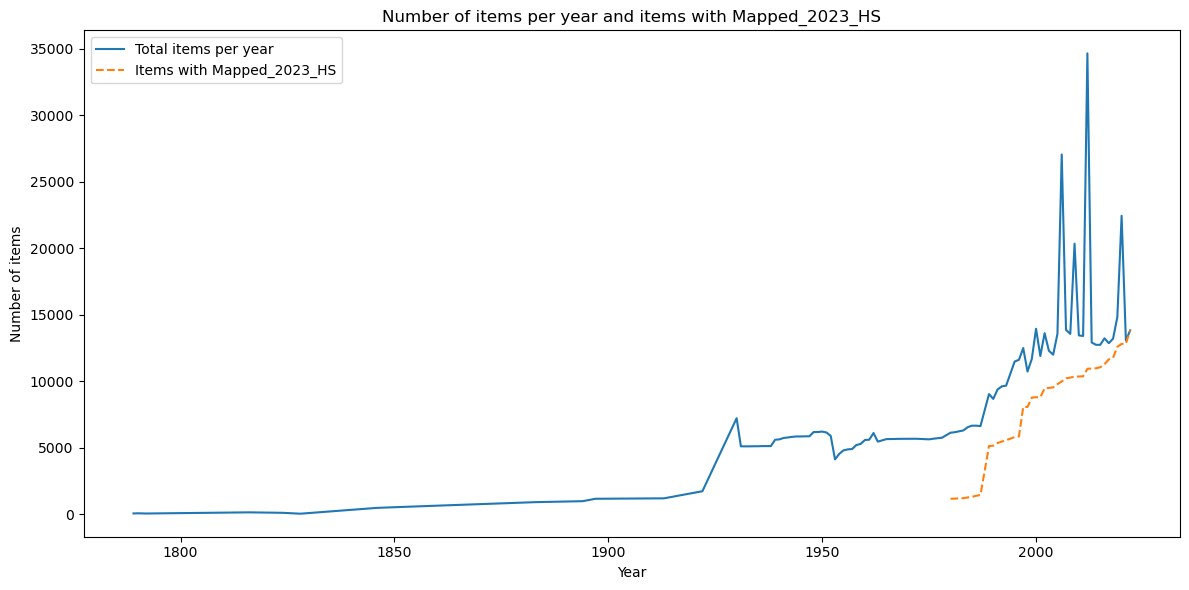

In [47]:
import matplotlib.pyplot as plt

# Count total items per year
total_per_year = df_N_N1.groupby('year_N').size()

# Count items per year with non-null Mapped_2023_HS
mapped_per_year = df_N_N1[df_N_N1['Mapped_2023_HS'].notna()].groupby('year_N').size()

plt.figure(figsize=(12,6))
plt.plot(total_per_year.index, total_per_year.values, label='Total items per year')
plt.plot(mapped_per_year.index, mapped_per_year.values, label='Items with Mapped_2023_HS', linestyle='--')
plt.xlabel('Year')
plt.ylabel('Number of items')
plt.title('Number of items per year and items with Mapped_2023_HS')
plt.legend()
plt.tight_layout()
plt.show()



In [49]:
df_N1_N

,from_year,to_year,year_N,year_N1,HS_N,HS_N1,Cosine_Similarity,Jaccard_Similarity,Levenshtein_Similarity,Combined_Similarity,Description_N,Description_N1,Mapped 2023 HS,Mapped 2023 Description
0,2023,2022,2022,2023,01013000,01013000,1.000000,1.000000,1.000000,1.000000,Live asses,Live asses,01013000,Live asses
1,2023,2022,2022,2023,01031000,01031000,1.000000,1.000000,1.000000,1.000000,Live purebred breeding swine,Live purebred breeding swine,01031000,Live purebred breeding swine
2,2023,2022,2022,2023,01022920,01022920,1.000000,1.000000,1.000000,1.000000,Cows imported specially for dairy purposes,Cows imported specially for dairy purposes,01022920,Cows imported specially for dairy purposes
3,2023,2022,2022,2023,01019040,01019040,1.000000,1.000000,1.000000,1.000000,Mules and hinnies not imported for immediate s...,Mules and hinnies not imported for immediate s...,01019040,Mules and hinnies not imported for immediate s...
4,2023,2022,2022,2023,01012900,01012900,1.000000,1.000000,1.000000,1.000000,Live horses other than purebred breeding horses,Live horses other than purebred breeding horses,01012900,Live horses other than purebred breeding horses
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
758523,1790,1789,1789,1790,nan,nan,1.000000,1.000000,1.000000,1.000000,"canes, walking sticks and whips","canes, walking sticks and whips",None,None
758524,1790,1789,1789,1790,nan,nan,0.846574,0.142857,0.560748,0.677248,"anchors, and wrought, tin, and pewter ware,","anchors, all wares of tin, pewter, or copper, ...",None,None
758525,1790,1789,1789,1790,nan,nan,0.329250,0.000000,0.228571,0.253332,manufactured tobacco,medicinal drugs,None,None
758526,1790,1789,1789,1790,nan,nan,0.836723,0.120000,0.594340,0.669140,"every coach, chariot or other four wheel carri...","All coaches, chariots, phaetons, chaises, chai...",None,None


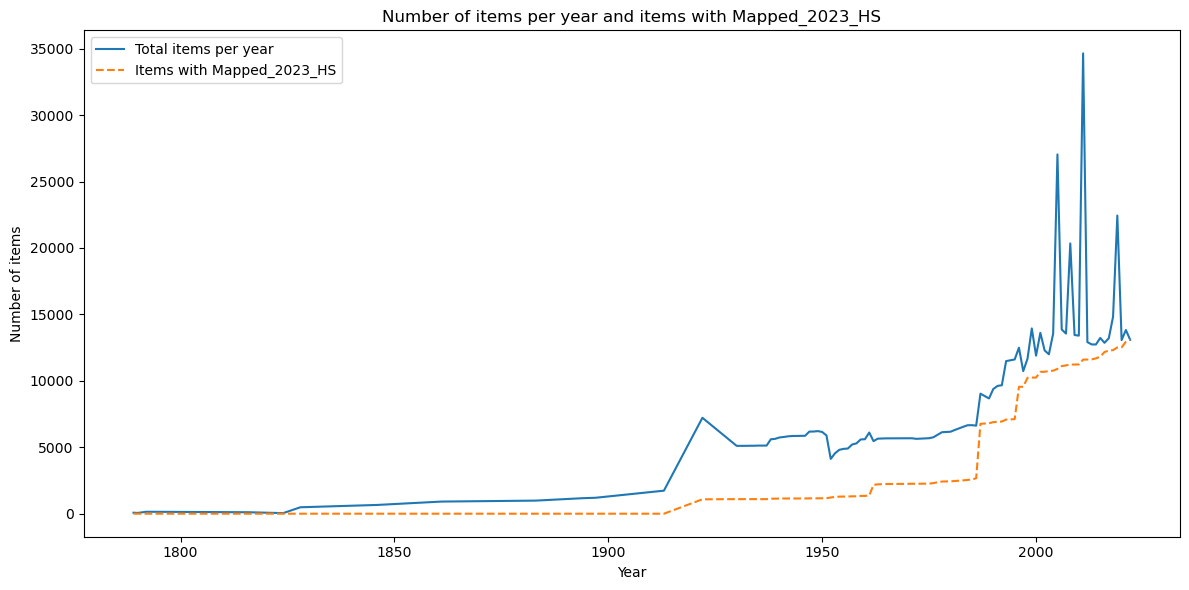

In [50]:
import matplotlib.pyplot as plt

# Count total items per year
total_per_year = df_N1_N.groupby('year_N').size()

# Count items per year with non-null Mapped_2023_HS
mapped_per_year = df_N1_N[df_N1_N['Mapped 2023 HS'].notna()].groupby('year_N').size()

plt.figure(figsize=(12,6))
plt.plot(total_per_year.index, total_per_year.values, label='Total items per year')
plt.plot(mapped_per_year.index, mapped_per_year.values, label='Items with Mapped_2023_HS', linestyle='--')
plt.xlabel('Year')
plt.ylabel('Number of items')
plt.title('Number of items per year and items with Mapped_2023_HS')
plt.legend()
plt.tight_layout()
plt.show()



In [51]:
df_N_N1

,from_year,to_year,year_N,year_N1,HS_N,HS_N1,Cosine_Similarity,Jaccard_Similarity,Levenshtein_Similarity,Combined_Similarity,Description_N,Description_N1,Mapped_2023_HS,Mapped_2023_Description
0,2022,2023,2022,2023,01051300,01051300,1.000000,1.000000,1.000000,1.000000,"Live ducks, weighing not more than 185 g each","Live ducks, weighing not more than 185 g each",01051300,"Live ducks, weighing not more than 185 g each"
1,2022,2023,2022,2023,01039100,01039100,1.000000,1.000000,1.000000,1.000000,"Live swine, other than purebred breeding swine...","Live swine, other than purebred breeding swine...",01039100,"Live swine, other than purebred breeding swine..."
2,2022,2023,2022,2023,01013000,01013000,1.000000,1.000000,1.000000,1.000000,Live asses,Live asses,01013000,Live asses
3,2022,2023,2022,2023,01023900,01023900,1.000000,1.000000,1.000000,1.000000,"Live buffalo, other than purebred breeding ani...","Live buffalo, other than purebred breeding ani...",01023900,"Live buffalo, other than purebred breeding ani..."
4,2022,2023,2022,2023,01012100,01012100,1.000000,1.000000,1.000000,1.000000,Live purebred breeding horses,Live purebred breeding horses,01012100,Live purebred breeding horses
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745501,1789,1790,1789,1790,NaN,NaN,1.000000,1.000000,1.000000,1.000000,"canes, walking sticks and whips","canes, walking sticks and whips",None,None
745502,1789,1790,1789,1790,NaN,NaN,0.942003,0.833333,0.944444,0.920513,"other goods, wares and merchandise","all other goods, wares and merchandise",None,None
745503,1789,1790,1789,1790,NaN,NaN,0.909181,0.300000,0.630137,0.759440,"hats of beaver, fur, wool, or mixture of either","hats of beaver, felt, wool",None,None
745504,1789,1790,1789,1790,NaN,NaN,0.828300,0.300000,0.658824,0.705692,"gold, silver, and plated ware, and jewelry and...","gold, silver and plated ware",None,None
